# NASDAQ-100 Microstructure: Feasibility Analysis

`config/setup.yaml` declares a cross-sectional intraday strategy: which NASDAQ-100 names trade,
how often the book turns over, what crossing the spread costs, and how the sample splits. This
notebook asks whether AlgoSeek bars support it, and fits nothing.

## Learning objectives

- Price a round trip from NBBO quotes, and read clearance off an exceedance curve scaled by
  each symbol's own cost
- Check the universe is quotable at every decision bar, that the return a signal rides does
  not persist to the next one, and that the declared folds fit the sample

## Book reference. Chapter 6, Sections 6.2-6.6. Reads AlgoSeek bars and `config/setup.yaml`,
and writes the per-symbol cost profile the backtest charges itself.

In [1]:
"""NASDAQ-100 Microstructure Case Study - Feasibility Analysis."""

import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml

from case_studies.utils.feasibility import exceedance_curve, fold_timeline, panel_acf
from data import load_nasdaq100_bars
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "nasdaq100_microstructure"
START_DATE = "2020-01-01"
MAX_SYMBOLS = 0  # 0 loads the declared universe; a positive value takes a deterministic subset

## Configuration

Every knob comes from `setup.yaml`, and `load_bars` stops every frame short of
`holdout_start`, so nothing in the holdout shapes a choice made here.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
PRIMARY_LABEL = SETUP["labels"]["primary"]
DECLARED_SYMBOLS = set(SETUP["universe"]["symbols"])
BREADTH_FLOOR = 2 * max(max(grid) for grid in SETUP["backtest"]["sweep"]["top_k_grid"].values())
PER_SHARE_USD = float(SETUP["costs"]["per_share"])
FRICTION_FLOOR_BPS = float(SETUP["costs"]["friction_floor_bps"])
COST_FEASIBLE = SETUP["universe"]["cost_feasible"]["validation"]
CADENCE = f"{SETUP['decision']['bar_frequency'].split('_')[0]}m"
HORIZONS = sorted({int(b.rstrip("min")) for b in SETUP["labels"]["variant_buffers"].values()})
WINDOW = {"start_date": START_DATE, "end_date": HOLDOUT_START, "max_symbols": MAX_SYMBOLS}

print(f"Development {START_DATE} to {HOLDOUT_START} | sealed holdout to {HOLDOUT_END}")
print(f"{len(DECLARED_SYMBOLS)} symbols, floor {BREADTH_FLOOR} | horizons {HORIZONS} minutes")

Development 2020-01-01 to 2021-07-01 | sealed holdout to 2021-12-31
114 symbols, floor 40 | horizons [5, 15, 60] minutes


In [4]:
def load_bars(frequency: str = "1m") -> pl.DataFrame:
    """Quoted bars over the development window, with the quote midpoint attached."""
    return (
        load_nasdaq100_bars(frequency=frequency, include_quotes=True, **WINDOW)
        .filter(
            pl.col("timestamp") < pl.lit(HOLDOUT_START).str.to_datetime(),
            pl.col("bid_close") > 0,
            pl.col("ask_close") >= pl.col("bid_close"),
        )
        .select(
            "timestamp",
            "symbol",
            "close",
            session=pl.col("timestamp").dt.date(),
            mid=(pl.col("bid_close") + pl.col("ask_close")) / 2,
            half_spread_usd=(pl.col("ask_close") - pl.col("bid_close")) / 2,
        )
        .sort(["symbol", "timestamp"])
    )

## A. Orientation

NASDAQ-100 names quote continuously, so a cross-sectional book can be rebalanced many times a
day rather than once. What it earns is the gap between how far prices move over a few bars and
what getting in and out costs, and at intraday horizons those two are the same order of
magnitude. Three questions follow: is the book quotable on every decision bar, is a typical
move large next to the round trip, and are there enough bars to evaluate on.

## B. Universe and cost feasibility

### B.1 Load and verify the declared universe

`close` alternates between bid and ask on consecutive prints and the midpoint does not, so
every return below is a midpoint return and every cost comes off the quote.

In [5]:
minute_bars = load_bars()
missing = sorted(DECLARED_SYMBOLS - set(minute_bars["symbol"].unique())) if not MAX_SYMBOLS else []
assert not missing, f"declared in setup.yaml but absent from the data: {missing}"
print(
    f"{minute_bars['symbol'].n_unique()} symbols, {len(minute_bars):,} quoted minutes, "
    f"{minute_bars['timestamp'].min()} to {minute_bars['timestamp'].max()}"
)

114 symbols, 14,904,457 quoted minutes, 2020-01-02 09:30:00 to 2021-06-30 15:59:00


### B.2 Breadth at every decision bar

A long-short book needs enough names on both legs when it rebalances, and the book it fills is
the cost-feasible subset `setup.yaml` freezes per split, not the declared universe. The bars
where it thins out are post-close prints on half-days, which a filter on clock time admits.

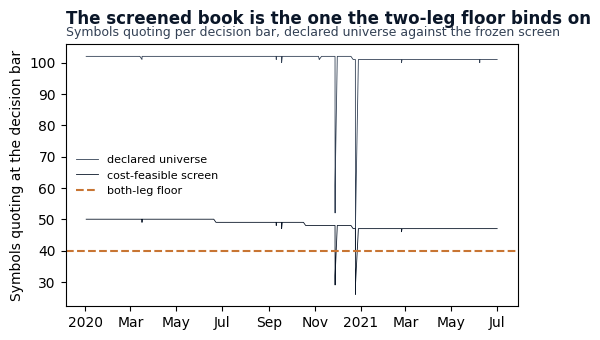

Declared 40 to 102 per bar, cost-feasible 26 to 50; under the floor of 40 on 20 of 9,802 bars, all on 2020-11-27, 2020-12-24


In [6]:
decision_bars = load_bars(CADENCE)
breadth = (
    decision_bars.group_by("timestamp")
    .agg(declared=pl.len(), screened=pl.col("symbol").is_in(COST_FEASIBLE).sum())
    .sort("timestamp")
)
thin = breadth.filter(pl.col("screened") < BREADTH_FLOOR)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ts = breadth["timestamp"]
ax.plot(ts, breadth["declared"], color=COLORS["neutral"], lw=0.6, label="declared universe")
ax.plot(ts, breadth["screened"], color=COLORS["blue"], lw=0.6, label="cost-feasible screen")
ax.axhline(BREADTH_FLOOR, color=COLORS["copper"], ls="--", lw=1.5, label="both-leg floor")
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.set_ylabel("Symbols quoting at the decision bar")
ax.legend(frameon=False, fontsize=8, loc="center left")
add_message_title(
    ax,
    "The screened book is the one the two-leg floor binds on",
    subtitle="Symbols quoting per decision bar, declared universe against the frozen screen",
)
plt.show()
print(
    f"Declared {breadth['declared'].min()} to {breadth['declared'].max()} per bar, cost-feasible "
    f"{breadth['screened'].min()} to {breadth['screened'].max()}; under the floor of "
    f"{BREADTH_FLOOR} on {len(thin)} of {len(breadth):,} bars, all on "
    + ", ".join(str(d) for d in thin["timestamp"].dt.date().unique().sort().to_list())
)

### B.3 What a round trip costs

`setup.yaml::costs` charges a per-share commission plus half the quoted spread on each side.
Half the spread is a price in cents rather than basis points: the same penny costs four times as
much on a twenty-five dollar share as on a hundred dollar one. Doubling it in bps and adding the
commission over the price is the screen's own proxy, frozen on a window ending before validation
starts, so its names track this ordering without matching it.

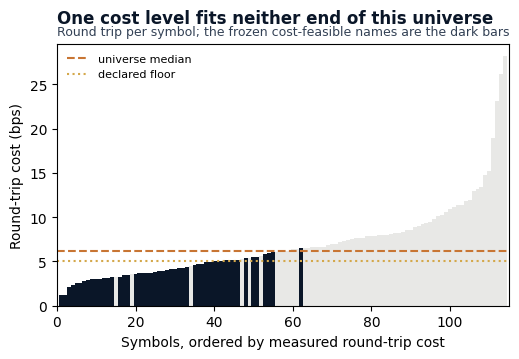

In [7]:
spread_bps = pl.col("half_spread_usd") / pl.col("mid") * 1e4
rt_cost = 2 * pl.col("median_half_spread_bps") + 2e4 * PER_SHARE_USD / pl.col("mean_price")
liquidity_profile = (
    minute_bars.group_by("symbol")
    .agg(
        median_half_spread_usd=pl.col("half_spread_usd").median(),
        median_half_spread_bps=spread_bps.median(),
        mean_price=pl.col("close").mean(),
    )
    .with_columns(rt_cost_bps_median=rt_cost)
    .sort("rt_cost_bps_median")
    .with_row_index("cost_rank", offset=1)
)
cost = liquidity_profile["rt_cost_bps_median"]
UNIVERSE_COST_BPS = float(cost.median())

tone = (COLORS["blue"], COLORS["silver_muted"])
bars = np.where(liquidity_profile["symbol"].is_in(COST_FEASIBLE), *tone)
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.bar(liquidity_profile["cost_rank"], cost, color=bars, width=1.0)
ax.axhline(UNIVERSE_COST_BPS, color=COLORS["copper"], ls="--", lw=1.5, label="universe median")
ax.axhline(FRICTION_FLOOR_BPS, color=COLORS["amber"], ls=":", lw=1.5, label="declared floor")
ax.set_xlim(0, len(liquidity_profile) + 1)
ax.set_xlabel("Symbols, ordered by measured round-trip cost")
ax.set_ylabel("Round-trip cost (bps)")
ax.legend(frameon=False, fontsize=8)
add_message_title(
    ax,
    "One cost level fits neither end of this universe",
    subtitle="Round trip per symbol; the frozen cost-feasible names are the dark bars",
)
plt.show()

### B.4 How long the carrier stays put

Rebalancing every bar is only worth the turnover if what the data says at one decision bar
still says something at the next. How long the midpoint return persists is an autocorrelation
computed inside each symbol, drawn over four cycles because further out most pairs would join
one session's end to the next one's start.

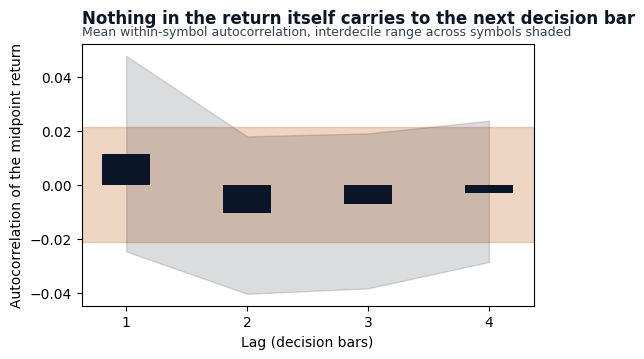

In [8]:
decision_returns = decision_bars.with_columns(
    ret=pl.col("mid").pct_change().over(["symbol", "session"])
).drop_nulls("ret")
acf = panel_acf(decision_returns, entity_col="symbol", value_col="ret", max_lags=4)[1:]

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.fill_between(acf["lag"], acf["acf_p10"], acf["acf_p90"], color=COLORS["blue"], alpha=0.15)
ax.bar(acf["lag"], acf["acf"], color=COLORS["blue"], width=0.4)
ax.axhspan(-acf["band"][0], acf["band"][0], color=COLORS["copper"], alpha=0.3, zorder=0)
ax.set_xticks(acf["lag"])
ax.set_xlabel("Lag (decision bars)")
ax.set_ylabel("Autocorrelation of the midpoint return")
add_message_title(
    ax,
    "Nothing in the return itself carries to the next decision bar",
    subtitle="Mean within-symbol autocorrelation, interdecile range across symbols shaded",
)
plt.show()

So a signal here cannot be the last return: Chapter 8 builds from the order-flow and quote
fields the return summarises away.

### B.5 Move scale against cost

Costs differ by more than an order of magnitude, so one cost line drawn on raw returns answers
the question for no symbol. Each move is divided by its own symbol's round trip instead, which
puts break-even at one; the horizons are the labels' and the moves are unsigned magnitudes.

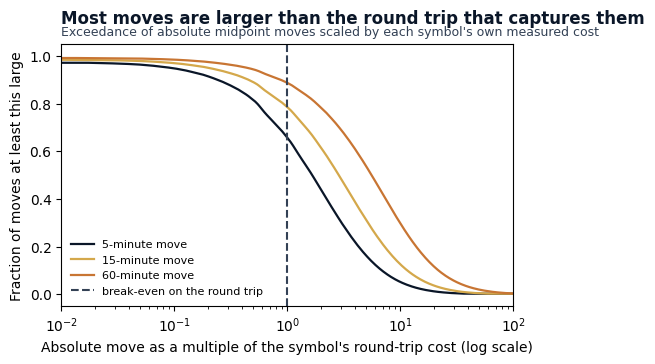

In [9]:
moves = (
    minute_bars.with_columns(
        (pl.col("mid").pct_change(h).over(["symbol", "session"]).abs() * 1e4).alias(f"h{h}")
        for h in HORIZONS
    )
    .join(liquidity_profile.select("symbol", "rt_cost_bps_median"), on="symbol")
    .with_columns((pl.col(f"h{h}") / pl.col("rt_cost_bps_median")).alias(f"m{h}") for h in HORIZONS)
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for h, color in zip(HORIZONS, (COLORS["blue"], COLORS["amber"], COLORS["copper"]), strict=True):
    multiple, fraction = exceedance_curve(moves[f"m{h}"].drop_nulls().to_numpy())
    ax.plot(multiple, fraction, color=color, lw=1.6, label=f"{h}-minute move")
ax.axvline(1, color=COLORS["neutral"], ls="--", lw=1.5, label="break-even on the round trip")
ax.set_xscale("log")
ax.set_xlim(0.01, 100)
ax.set_xlabel("Absolute move as a multiple of the symbol's round-trip cost (log scale)")
ax.set_ylabel("Fraction of moves at least this large")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "Most moves are larger than the round trip that captures them",
    subtitle="Exceedance of absolute midpoint moves scaled by each symbol's own measured cost",
)
plt.show()

In [10]:
print(f"Round-trip cost {cost.min():.2f} to {cost.max():.2f} bps, median {UNIVERSE_COST_BPS:.2f}")
for h in HORIZONS:
    med, share = moves.select(pl.col(f"h{h}").median(), (pl.col(f"m{h}") > 1).mean()).row(0)
    print(f"  {h:>2}-minute move: median {med:.1f} bps, clears its own round trip {share:.3f}")

Round-trip cost 1.16 to 28.17 bps, median 6.16


   5-minute move: median 9.8 bps, clears its own round trip 0.658


  15-minute move: median 16.9 bps, clears its own round trip 0.786


  60-minute move: median 33.1 bps, clears its own round trip 0.888


Measured round-trip cost runs from 1.16 bps on the tightest-quoted name to 28.17 bps on the
widest, with a universe median of 6.16 bps. The median absolute midpoint move is 9.8 bps over
5 minutes, 16.9 bps over 15 and 33.1 bps over 60, and the fraction of moves clearing the
symbol's own round trip is 0.658, 0.786 and 0.888 at those horizons. A typical move at the
traded cadence is under three times the round trip, and a strategy keeps only the part of it
the sign was right about.

## C. Design decisions

### C.1 Cadence. `setup.yaml::decision.bar_frequency` rebalances on the fifteen-minute bar and
`execution_delay` puts the trade in the following one. B.5 prices that from both sides: a
shorter horizon clears the round trip less often, a longer one spends fewer decisions on the
same sample. Scoring a bar with its own close and trading there would restate the signal's
own price, so the delay is declared once here.

### C.2 Kill conditions. Three falsifiable thresholds, tested where the evidence for each
exists rather than here: no feature reaches an information coefficient distinguishable from
zero across the folds, Chapter 8's measurement; gross expected edge stays under the measured
round trip, which Chapter 17 prices; the signal dies inside the one-bar delay, Chapter 7's.

### C.3 Mapping class. `setup.yaml::mapping.class` ranks symbols each bar and holds both legs.
These names borrow cheaply, so the short leg costs what the long leg does, and holding both
strips out the market move a cross-sectional score cannot claim to predict.

## D. Walk-forward structure

### D.1 Effective sample size. What evaluation spends is decision bars, not rows, and this
panel is wide rather than long: a hundred symbols share each bar, and what moved the market.

In [11]:
print(
    f"Decision bars {len(breadth):,} over {decision_bars['session'].n_unique():,} sessions "
    f"| symbols per decision bar {breadth['declared'].mean():.0f}"
)

Decision bars 9,802 over 377 sessions | symbols per decision bar 102


### D.2 Fold demonstration

`generate_cv_splits` derives the folds from `setup.yaml::evaluation` alone, working back from the
holdout, and between training and validation sits a purge gap the width of the label horizon.

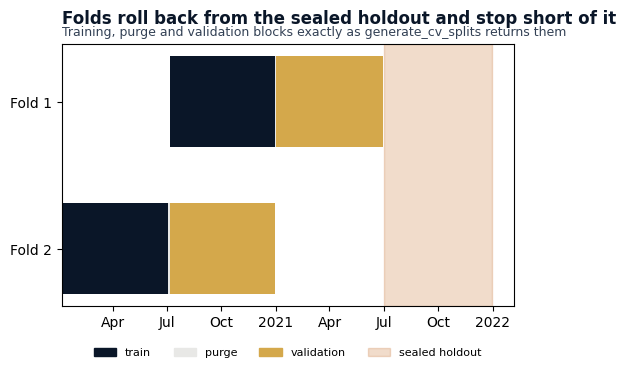

In [12]:
splits = generate_cv_splits(
    decision_bars.select("timestamp"),
    case_study_id=CASE_STUDY_ID,
    label_buffer=SETUP["labels"]["buffer"],
    date_col="timestamp",
)
last_val = max(s["val_end"] for s in splits)
assert len(splits) == SETUP["evaluation"]["n_splits"], "fold count differs from setup.yaml"
assert last_val < np.datetime64(HOLDOUT_START), "a fold reaches into the holdout"

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
fold_timeline(ax, splits, holdout=(HOLDOUT_START, HOLDOUT_END))
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
add_message_title(
    ax,
    "Folds roll back from the sealed holdout and stop short of it",
    subtitle="Training, purge and validation blocks exactly as generate_cv_splits returns them",
)
plt.show()

## E. Derived artifacts. `setup.yaml::costs.asset_spreads_source` names
`liquidity_profile.parquet`: the cost preset joins `median_half_spread_usd` per symbol, and
`_build_cost_feasible_universe.py` ranks on it to freeze the screen.

In [13]:
profile_path = CASE_DIR / "liquidity_profile.parquet"
liquidity_profile.write_parquet(profile_path)
print(f"Written: {profile_path.name} ({len(liquidity_profile)} symbols)")

Written: liquidity_profile.parquet (114 symbols)


## F. Findings vs `setup.yaml`

| Knob | Evidence | Revise it when |
|---|---|---|
| `universe.symbols` | B.2 breadth per decision bar | breadth falls under the positions the sweep asks for on either leg |
| `universe.cost_feasible` | B.3 cost ordering and where the screen cuts | the screened names stop being the cheap end of the ordering |
| `costs.model` | B.3 measured per-symbol half-spread | one level fits the cross-section, or the vendor stops supplying quotes |
| `decision.bar_frequency` | B.4 persistence, B.5 clearance by horizon | a longer horizon clears cost often enough to pay for the decisions it gives up |
| `evaluation.n_splits` | D.1 decision bars, D.2 fold boundaries | the folds no longer fit the development window |

In [14]:
print(
    f"universe.n_assets {SETUP['universe']['n_assets']}, screened breadth "
    f"{breadth['screened'].min()} to {breadth['screened'].max()} | costs.model "
    f"{SETUP['costs']['model']}, measured round trip median "
    f"{UNIVERSE_COST_BPS:.2f} bps against a declared floor of {FRICTION_FLOOR_BPS:.0f} bps\n"
    f"decision.bar_frequency {SETUP['decision']['bar_frequency']} | labels.primary "
    f"{PRIMARY_LABEL} | evaluation.n_splits {SETUP['evaluation']['n_splits']}, generated "
    f"{len(splits)}, last validation ends {last_val.date()}, holdout untouched"
)

universe.n_assets 114, screened breadth 26 to 50 | costs.model per_share_plus_spread, measured round trip median 6.16 bps against a declared floor of 5 bps
decision.bar_frequency 15_minute | labels.primary fwd_ret_15m | evaluation.n_splits 2, generated 2, last validation ends 2021-06-30, holdout untouched


The declared universe carries 40 to 102 symbols per decision bar, but the cost-feasible book
carries 26 to 50 and falls under the floor of 40 on 20 of 9,802 bars, every one of them a
post-close print on 2020-11-27 or 2020-12-24. The measured round-trip median of 6.16 bps sits
above the friction floor of 5 bps `setup.yaml` declares, so that floor is the optimistic end
of what this universe charges. Two folds are generated, the last validation ends 2021-06-30.

## Key takeaways

1. **Measure cost per symbol where the quotes exist**: a spread is a price in cents, and one
   conversion to basis points misstates both ends of the ordering.
2. **Scale each move by its own cost before comparing horizons**, so break-even is one.
3. **Take midpoint returns, not traded closes**: a traded price alternates between bid and ask.
4. **Compute a panel autocorrelation inside one entity**: pooling wider measures its joins.

### Known limitations. Cost is the quoted spread plus commission at the size one bar absorbs
and impact enters at the cost stage; a horizon counted in bars is the clock interval it names
for all but a fiftieth of them.

**Next**: labels at the declared horizons, built on midpoint prices over this same window.